# Simple Potts Boundary Comparison

This notebook studies the critical three-state quantum Potts chain using the reusable `PottsChain` class from this project.

The model and its operators are **not defined here**. The notebook only chooses parameters, runs DMRG, measures the resulting states, and plots the results.

We will:

1. Construct Potts chains with several exact boundary conditions.
2. Find their ground states with finite DMRG.
3. Check the state probabilities at the restricted edges.
4. Compare their entanglement-entropy profiles.
5. Fit the leading open-chain CFT form and compare with the expected c.

## 0. Imports

The path setup lets the notebook work when Jupyter is launched either from `potts_model_project`, its `notebooks` folder, or the surrounding workspace.

In [48]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import tenpy
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS


def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "potts_model_project",
        cwd.parent,
        cwd.parent / "potts_model_project",
    ]
    for candidate in candidates:
        if (candidate / "potts_model" / "potts.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the potts_model_project folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from potts_model import PottsChain

print("Project root:", PROJECT_ROOT)
print("TeNPy version:", tenpy.__version__)

Project root: /Users/Aditya/Desktop/Third Year Summer Project/potts_model_project
TeNPy version: 1.1.0


## 1. Hamiltonian convention

The imported class implements the 3-state Potts hamiltonian in the form:

$$
H=-J\sum_{\langle i,j\rangle}\sum_{\mu=1}^{3}P_i^\mu P_j^\mu-h\sum_iP_i,
$$

where

$$
P^\mu=|\mu\rangle\langle\mu|-\frac{I}{3},
\qquad
P=|\lambda_0\rangle\langle\lambda_0|-\frac{I}{3},
$$

and

$$
|\lambda_0\rangle=\frac{|1\rangle+|2\rangle+|3\rangle}{\sqrt{3}}.
$$

There is no `ClockChain` sign conversion in this notebook. For the ferromagnetic critical model discussed in the paper, $J=h$, and the expected central charge is $c=4/5$.

## 2. Numerical parameters

`RUN_FAST=True` is suitable for checking that the notebook works. Set it to `False` for a more serious comparison.

In [49]:
RUN_FAST = True
RUN_SLOW = False

if RUN_FAST:
    R = 31
    chi_max = 50
    max_sweeps = 12
elif RUN_SLOW:
    R = 60
    chi_max = 80
    max_sweeps = 20
else:
    R = 40
    chi_max = 80
    max_sweeps = 12



J = -1.0
h = -1.0
C_TARGET = 4.0 / 5.0

dmrg_params = {
    "mixer": True,
    "max_sweeps": max_sweeps,
    # Exact edge restrictions use a TrivialLattice whose single TeNPy unit
    # cell contains all R sites. This is still a 1D chain, so overriding
    # TeNPy's default 18-sites-per-ring safety threshold is appropriate.
    "max_N_sites_per_ring": R,
    "trunc_params": {
        "chi_max": chi_max,
        "svd_min": 1e-10,
    },
}

print(f"R={R}, J={J}, h={h}, chi_max={chi_max}, max_sweeps={max_sweeps}")
print("Expected critical central charge:", C_TARGET)

R=31, J=-1.0, h=-1.0, chi_max=50, max_sweeps=12
Expected critical central charge: 0.8


## 3. Boundary conditions

The class accepts the following values independently at the left and right edges:

- `1`, `2`, `3`: retain only that state (fixed boundary).
- `-1`, `-2`, `-3`: remove that state and retain the other two (forbidden/partially fixed boundary).
- `"free"` or `None`: retain all three states.

These are exact Hilbert-space restrictions. There is no boundary-field strength to tune.

The dictionary below includes the fixed cases from the earlier comparison and several examples of the new forbidden-state interface. Remove entries if you want a quicker run.

In [50]:
all_boundary_cases = {
    "free|free": {"left": "free", "right": "free"},
    "1|1": {"left": 1, "right": 1},
    "1|2": {"left": 1, "right": 2},
    "1|3": {"left": 1, "right": 3},
    "1|-1": {"left": 1, "right": -1},
    "1|-2": {"left": 1, "right": -2},
    "1|free": {"left": 1, "right": "free"},
    "-1|-1": {"left": -1, "right": -1},
    "-1|-2": {"left": -1, "right": -2},
    "-1|free": {"left": -1, "right": "free"},
    "periodic": {
        "left": "free",
        "right": "free",
        "periodic": True,
        "order": "default",
    },

}

# Keep the long R=60 run focused on the two geometries being compared.
# Replace this list with list(all_boundary_cases) to run every case.
selected_case_labels = ["free|free", "1|1", "1|2"]
boundary_cases = {
    label: all_boundary_cases[label]
    for label in selected_case_labels
}

list(boundary_cases)

['free|free', '1|1', '1|2']

## 4. Model builder and DMRG runner

For each case, the runner stores:

- the model and optimized MPS;
- the total energy and energy per physical site;
- the entanglement entropy at every bond cut;
- the three state-probability profiles $\langle Q_1\rangle$, $\langle Q_2\rangle$, and $\langle Q_3\rangle$.

In [51]:
def build_model(case):
    return PottsChain.from_parameters(
        L=R,
        J=J,
        h=h,
        left_boundary=case["left"],
        right_boundary=case["right"],
        periodic=case.get("periodic", False),
        order=case.get("order", "default"),
    )


def run_dmrg_for_case(label, case):
    model = build_model(case)
    initial_state = model.initial_product_state(bulk_state=1)

    psi = MPS.from_product_state(
        model.lat.mps_sites(),
        initial_state,
        bc=model.lat.bc_MPS,
        unit_cell_width=model.lat.mps_unit_cell_width,
    )

    engine = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
    energy, psi = engine.run()

    state_probabilities = {
        state: np.real(psi.expectation_value(f"Q{state}"))
        for state in (1, 2, 3)
    }

    return {
        "label": label,
        "case": case,
        "model": model,
        "psi": psi,
        "energy": float(np.real(energy)),
        "energy_per_site": float(np.real(energy) / R),
        "r": np.arange(1, R),
        "entropy": np.asarray(psi.entanglement_entropy(), dtype=float),
        "state_probabilities": state_probabilities,
    }

## 5. Run all boundary cases

This is the expensive cell. Its runtime grows with `R`, `chi_max`, `max_sweeps`, and the number of entries in `boundary_cases`.

In [52]:
results = {}

for label, case in boundary_cases.items():
    print(f"Running {label} ...")
    results[label] = run_dmrg_for_case(label, case)
    print("  bond dimensions:", results[label]["psi"].chi)

print("Done.")

Running free|free ...
  bond dimensions: [3, 9, 27, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 27, 9, 3]
Running 1|1 ...
  bond dimensions: [1, 3, 9, 24, 38, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 41, 25, 9, 3, 1]
Running 1|2 ...
  bond dimensions: [1, 3, 9, 23, 41, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 43, 25, 9, 3, 1]
Done.


## 6. Energies2 and exact boundary checks

For a fixed boundary `s`, $\langle Q_s\rangle$ at that edge must be exactly 1. For a forbidden boundary `-s`, $\langle Q_s\rangle$ must be exactly 0. Free boundaries have no single target probability.

In [53]:
def boundary_diagnostic(result, side):
    code = result["case"][side]
    if code in (None, "free", 0):
        return np.nan, "free"

    edge_index = 0 if side == "left" else -1
    state = abs(int(code))
    probability = result["state_probabilities"][state][edge_index]
    target = 1.0 if int(code) > 0 else 0.0
    return probability, f"target={target:.0f}"


print(f"{'boundary':>12} {'E/site':>14} {'left check':>22} {'right check':>22}")
print("-" * 76)

for label, result in results.items():
    left_value, left_target = boundary_diagnostic(result, "left")
    right_value, right_target = boundary_diagnostic(result, "right")
    left_text = "free" if np.isnan(left_value) else f"{left_value:.8f} ({left_target})"
    right_text = "free" if np.isnan(right_value) else f"{right_value:.8f} ({right_target})"
    print(
        f"{label:>12} {result['energy_per_site']:14.8f} "
        f"{left_text:>22} {right_text:>22}"
    )

    boundary         E/site             left check            right check
----------------------------------------------------------------------------
   free|free    -0.59776198                   free                   free
         1|1    -0.57835233  1.00000000 (target=1)  1.00000000 (target=1)
         1|2    -0.57787271  1.00000000 (target=1)  1.00000000 (target=1)


## 7. Inspect one state-probability profile

The operators `Q1`, `Q2`, and `Q3` are ordinary state projectors. Their expectation values sum to one on every site.

Maximum |sum_mu <Q_mu> - 1|: 1.3322676295501878e-15


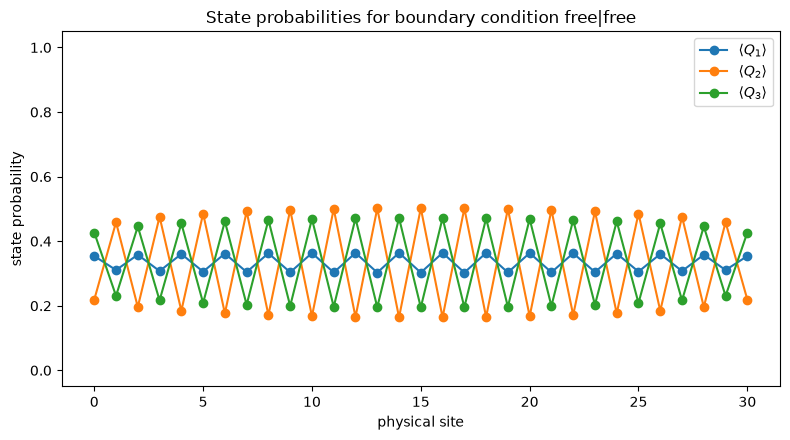

In [54]:
selected_case = "free|free"
selected = results[selected_case]
sites = np.arange(R)

plt.figure(figsize=(8, 4.5))
for state, probabilities in selected["state_probabilities"].items():
    plt.plot(sites, probabilities, "o-", label=fr"$\langle Q_{state}\rangle$")

probability_sum = sum(selected["state_probabilities"].values())
print("Maximum |sum_mu <Q_mu> - 1|:", np.max(np.abs(probability_sum - 1.0)))

plt.xlabel("physical site")
plt.ylabel("state probability")
plt.title(f"State probabilities for boundary condition {selected_case}")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()

## 8. Compare the entanglement profiles

$S(r,R)$ is the von Neumann entropy across the cut between physical sites $r-1$ and $r$. The first and last points can be strongly affected by the exact edge restrictions.

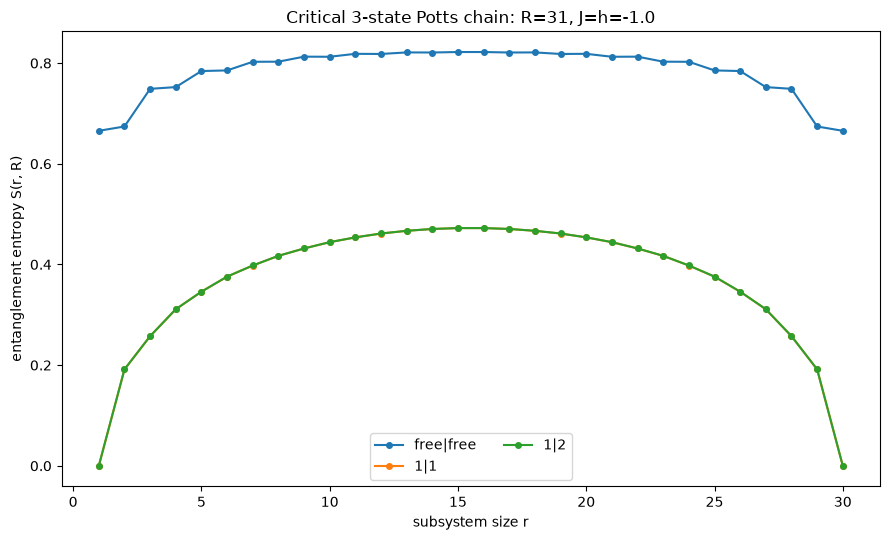

In [55]:
plt.figure(figsize=(9, 5.5))

for label, result in results.items():
    plt.plot(result["r"], result["entropy"], "o-", markersize=4, label=label)

plt.xlabel("subsystem size r")
plt.ylabel("entanglement entropy S(r, R)")
plt.title(f"Critical 3-state Potts chain: R={R}, J=h={J}")
plt.legend(ncols=2)
plt.tight_layout()

## 9. Open and periodic CFT fits

For a critical open chain, the leading smooth form is

$$
S(r,R)\approx\frac{c}{6}\log\left[\frac{2R}{\pi}\sin\left(\frac{\pi r}{R}\right)\right]+A.
$$

For a periodic chain, the corresponding form is

$$
S_{\mathrm{PBC}}(r,R)\approx\frac{c}{3}\log\left[\frac{R}{\pi}\sin\left(\frac{\pi r}{R}\right)\right]+A.
$$

The fitting code checks `model.is_periodic` automatically. It uses $c_{\mathrm{fit}}=6\times\text{slope}$ for open chains and $c_{\mathrm{fit}}=3\times\text{slope}$ for the periodic chain. The expected value is $c=4/5$ for the ferromagnetic case and $c=1$ for the antiferromagnetic case.

This is only a rough fit: it ignores finite-size corrections and boundary-dependent corrections. We exclude several points near each edge.

In [56]:
def log_chord_length(r, R, periodic=False):
    prefactor = R / np.pi if periodic else 2.0 * R / np.pi
    return np.log(prefactor * np.sin(np.pi * r / R))


def fit_entropy_profile(r, entropy, R, periodic=False, edge_skip=3):
    x = log_chord_length(r, R, periodic=periodic)
    mask = (r > edge_skip) & (r < R - edge_skip)
    if np.count_nonzero(mask) < 2:
        raise ValueError("Not enough interior points for the requested fit.")

    slope, intercept = np.polyfit(x[mask], entropy[mask], deg=1)
    central_charge_factor = 3.0 if periodic else 6.0
    return {
        "x": x,
        "mask": mask,
        "geometry": "periodic" if periodic else "open",
        "slope": slope,
        "intercept": intercept,
        "fit": slope * x + intercept,
        "c_fit": central_charge_factor * slope,
    }


fits = {
    label: fit_entropy_profile(
        result["r"],
        result["entropy"],
        R,
        periodic=result["model"].is_periodic,
    )
    for label, result in results.items()
}

print(f"{'boundary':>12} {'geometry':>10} {'slope':>12} {'c_fit':>12} {'c_fit - 4/5':>16}")
print("-" * 68)
for label, fit_result in fits.items():
    print(
        f"{label:>12} {fit_result['geometry']:>10} "
        f"{fit_result['slope']:12.6f} "
        f"{fit_result['c_fit']:12.6f} "
        f"{fit_result['c_fit'] - C_TARGET:16.6f}"
    )

    boundary   geometry        slope        c_fit      c_fit - 4/5
--------------------------------------------------------------------
   free|free       open     0.067350     0.404102        -0.395898
         1|1       open     0.173987     1.043923         0.243923
         1|2       open     0.173880     1.043278         0.243278


## 10. Individual fit plots

Each panel compares the DMRG profile with the leading smooth CFT fit for the free|free or periodic case. For fixed BC, the plotting fails of course> I'm not sure what the plotting function is.

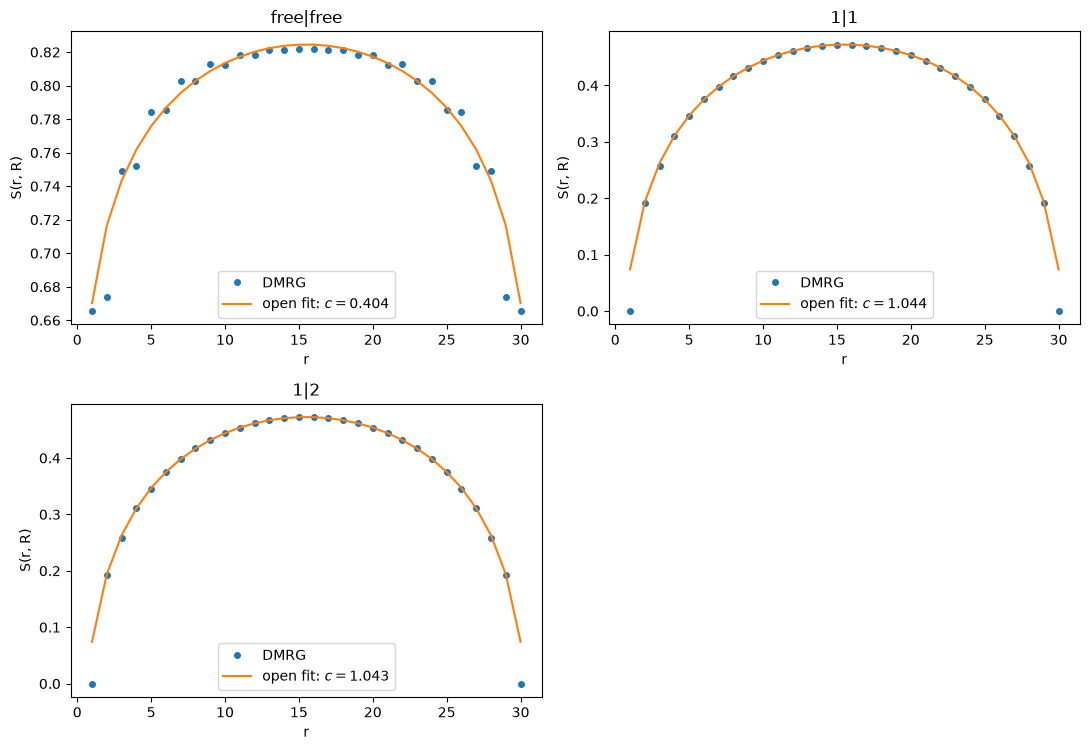

In [57]:
n_cases = len(results)
n_cols = 2
n_rows = int(np.ceil(n_cases / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.8 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for ax, (label, result) in zip(axes_flat, results.items()):
    fit_result = fits[label]
    ax.plot(result["r"], result["entropy"], "o", markersize=4, label="DMRG")
    ax.plot(
        result["r"],
        fit_result["fit"],
        "-",
        label=fr"{fit_result['geometry']} fit: $c={fit_result['c_fit']:.3f}$",
    )
    ax.set_title(label)
    ax.set_xlabel("r")
    ax.set_ylabel("S(r, R)")
    ax.legend()

for ax in axes_flat[n_cases:]:
    ax.axis("off")

plt.tight_layout()

## 11. Periodic-chain interpretation

The `periodic` case is included in the plots and fitted with the periodic $c/3$ formula. It deliberately uses `order="default"`, so each MPS cut corresponds to the physically contiguous block $\{0,\ldots,r-1\}$ and the entropy curve has its usual meaning.

Using `order="folded"` can make periodic DMRG more efficient, but then the MPS cuts describe folded, generally noncontiguous sets of physical sites. The resulting `psi.entanglement_entropy()` curve should not be interpreted as the standard contiguous-block $S(r,R)$.